## Import libraries


In [1]:
import os
import pickle
import sys
import time

source_folder = "/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/src"
sys.path.append(source_folder)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from utils.utils import evaluate_and_save_outputs, load_config, save_config, set_seed

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

import warnings

warnings.filterwarnings("ignore")

out_dir = "/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/output/figures"

## Read the Germany shapefile


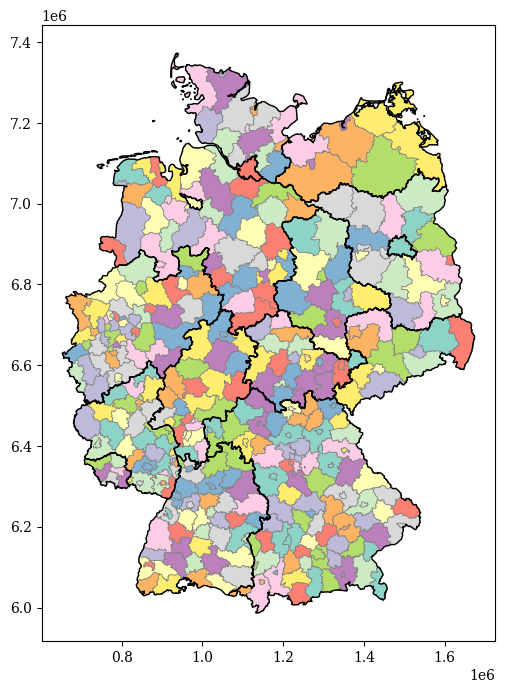

(16, 6) (400, 6)


,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,geometry
0,DE11B,3,DE,Main-Tauber-Kreis,Main-Tauber-Kreis,"POLYGON ((1074230.536 6408356.046, 1073820.827..."
1,DE11C,3,DE,Heidenheim,Heidenheim,"MULTIPOLYGON (((1131091.261 6235073.568, 11312..."
2,DE11D,3,DE,Ostalbkreis,Ostalbkreis,"MULTIPOLYGON (((1141777.678 6284962.486, 11412..."
3,DE121,3,DE,"Baden-Baden, Stadtkreis","Baden-Baden, Stadtkreis","MULTIPOLYGON (((910859.613 6248068.047, 913127..."
4,DE122,3,DE,"Karlsruhe, Stadtkreis","Karlsruhe, Stadtkreis","POLYGON ((938225.711 6286986.826, 940668.057 6..."


In [2]:
# Read the NUTS1 and NUTS3 shapefile for DE
de_nuts1_gdf = gpd.read_file(
    os.path.join("/beegfs/halder/DATA/", "DE_NUTS", "DE_NUTS_3.shp")
)
de_nuts1_gdf = de_nuts1_gdf[
    de_nuts1_gdf["LEVL_CODE"] == 1
]  # filter only NUT1 level code

de_nuts3_gdf = gpd.read_file(
    os.path.join("/beegfs/halder/DATA/", "DE_NUTS", "DE_NUTS_3.shp")
)
de_nuts3_gdf = de_nuts3_gdf[
    de_nuts3_gdf["LEVL_CODE"] == 3
]  # filter only NUT3 level code

fig, ax = plt.subplots(figsize=(8, 8))
de_nuts3_gdf.plot(
    ax=ax,
    column="NUTS_NAME",
    cmap="Set3",
    edgecolor="grey",
    linewidth=0.5,
    label="NUTS3",
)
de_nuts1_gdf.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1, label="NUTS1")
plt.show()

print(de_nuts1_gdf.shape, de_nuts3_gdf.shape)
de_nuts3_gdf.head()

## Prepare the results


In [3]:
# Function to prepare results
def prepare_results(model_name, crop, month, baseline=False):
    target_mean = cfg.scalers["yield_mean"]
    target_std = cfg.scalers["yield_std"]

    train_dataset = pd.read_parquet(
        f"/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/data/processed/{crop}/timeseries/DE11A_2004.parquet"
    )
    train_dataset["date"] = pd.to_datetime(train_dataset["date"]).dt.strftime("%b-%d")
    date_list = train_dataset["date"].tolist()[: model_config.get("seq_length")]

    if baseline != True:
        result_dir = os.path.join(
            f"/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/src/train/forecast/{crop}/{month}"
        )

    else:
        result_dir = os.path.join(
            f"/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/src/train/baseline/{crop}/{month}/{model_name}"
        )

    with open(os.path.join(result_dir, f"train_outputs.pkl"), "rb") as f:
        train_results = pickle.load(f)

    with open(os.path.join(result_dir, f"validation_outputs.pkl"), "rb") as f:
        val_results = pickle.load(f)

    with open(os.path.join(result_dir, f"test_outputs.pkl"), "rb") as f:
        test_results = pickle.load(f)

    combined_results = {
        k: np.concatenate([train_results[k], test_results[k], val_results[k]], axis=0)
        for k in test_results.keys()
    }

    # Prepare final predictions
    preds = combined_results["prediction"] * target_std + target_mean
    actuals = combined_results["target"] * target_std + target_mean
    prediction_df = pd.DataFrame(
        preds, columns=[f"pred_yield_q{i}" for i in model_config["quantiles"]]
    )
    prediction_df["target_yield"] = actuals
    prediction_df["year"] = combined_results["year"]
    prediction_df["NUTS_ID"] = combined_results["NUTS_ID"]
    prediction_df = prediction_df[
        ["NUTS_ID", "year", "target_yield"]
        + [f"pred_yield_q{i}" for i in model_config["quantiles"]]
    ]
    prediction_df.sort_values(by=["year", "NUTS_ID"], inplace=True)
    prediction_df.reset_index(drop=True, inplace=True)

    if baseline == False:
        keys_to_keep = {
            "NUTS_ID",
            "year",
            "static_weights",
            "temporal_weights",
            "attention_weights",
        }

        weights = {
            k: combined_results[k] for k in keys_to_keep if k in combined_results
        }

        # Prepare the static weights dataframe
        static_weights_df = pd.DataFrame(
            weights["static_weights"][:, :, 0], columns=cfg.static_real_variables
        )
        static_weights_df["NUTS_ID"] = weights["NUTS_ID"]
        static_weights_df["year"] = weights["year"]
        static_weights_df = static_weights_df[
            ["NUTS_ID", "year"] + cfg.static_real_variables
        ]
        static_weights_df.sort_values(by=["year", "NUTS_ID"], inplace=True)
        static_weights_df.reset_index(drop=True, inplace=True)

        # Prepare the temporal weights dataframe
        temporal_weights_array = weights["temporal_weights"][:, :, :, 0]
        n_samples, n_timesteps, n_vars = temporal_weights_array.shape

        temporal_weights_df = pd.DataFrame(
            temporal_weights_array.reshape(-1, n_vars), columns=cfg.time_varying_real
        )

        temporal_weights_df["NUTS_ID"] = np.repeat(weights["NUTS_ID"], n_timesteps)
        temporal_weights_df["year"] = np.repeat(weights["year"], n_timesteps)
        temporal_weights_df["timestep"] = np.tile(range(len(date_list)), n_samples)

        temporal_weights_df = temporal_weights_df[
            ["NUTS_ID", "year", "timestep"] + cfg.time_varying_real
        ]

        temporal_weights_df.sort_values(
            by=["year", "NUTS_ID", "timestep"], inplace=True
        )

        temporal_weights_df.reset_index(drop=True, inplace=True)

        result = (
            prediction_df,
            static_weights_df,
            temporal_weights_df,
            date_list,
        )

        return result

    else:
        return (
            prediction_df,
            date_list,
        )

In [4]:
# Get results for all crops for CropFusionNet and all baselines
crops = ["winter_wheat", "winter_barley", "silage_maize"]

crop_labels = {
    "winter_barley": "Winter Barley",
    "winter_wheat": "Winter Wheat",
    "silage_maize": "Silage Maize",
}
# Forecast month per crop
crop_months = {
    "winter_barley": "Jul",
    "winter_wheat": "Jul",
    "silage_maize": "Sep",
}

baseline_models = ["VanillaLSTM", "SimpleTransformer", "ResCNN"]
baseline_labels = {
    "VanillaLSTM": "Vanilla LSTM",
    "SimpleTransformer": "Simple Transformer",
    "ResCNN": "ResCNN",
}

# Load and store all results in a dictionary keyed by crop name
all_crop_results = {}
for crop_name in crops:
    global cfg, model_config, train_config
    cfg, model_config, train_config = load_config(crop_name)
    month = crop_months[crop_name]

    # CropFusionNet (main model)
    prediction_df, static_weights_df, temporal_weights_df, date_list = prepare_results(
        "CropFusionNet", crop=crop_name, month=month, baseline=False
    )
    all_crop_results[crop_name] = {
        "CropFusionNet": {
            "prediction_df": prediction_df,
            "static_weights_df": static_weights_df,
            "temporal_weights_df": temporal_weights_df,
            "date_list": date_list,
        }
    }
    print(f"[{crop_labels[crop_name]}] CropFusionNet: {prediction_df.shape[0]} samples")

    # Baseline models
    for model_name in baseline_models:
        pred_df_bl, date_list_bl = prepare_results(
            model_name, crop=crop_name, month=month, baseline=True
        )
        all_crop_results[crop_name][model_name] = {
            "prediction_df": pred_df_bl,
            "date_list": date_list_bl,
        }
        print(
            f"[{crop_labels[crop_name]}] {baseline_labels[model_name]}: {pred_df_bl.shape[0]} samples"
        )

[Winter Wheat] CropFusionNet: 7377 samples
[Winter Wheat] Vanilla LSTM: 7377 samples
[Winter Wheat] Simple Transformer: 7377 samples
[Winter Wheat] ResCNN: 7377 samples
[Winter Wheat] ResCNN: 7377 samples
[Winter Barley] CropFusionNet: 7100 samples
[Winter Barley] Vanilla LSTM: 7100 samples
[Winter Barley] Simple Transformer: 7100 samples
[Winter Barley] ResCNN: 7100 samples
[Winter Barley] CropFusionNet: 7100 samples
[Winter Barley] Vanilla LSTM: 7100 samples
[Winter Barley] Simple Transformer: 7100 samples
[Winter Barley] ResCNN: 7100 samples
[Silage Maize] CropFusionNet: 6823 samples
[Silage Maize] Vanilla LSTM: 6823 samples
[Silage Maize] Simple Transformer: 6823 samples
[Silage Maize] CropFusionNet: 6823 samples
[Silage Maize] Vanilla LSTM: 6823 samples
[Silage Maize] Simple Transformer: 6823 samples
[Silage Maize] ResCNN: 6823 samples
[Silage Maize] ResCNN: 6823 samples


## Variable Mapping


In [5]:
variable_name_mapping = {
    # ------------------- Climate / Meteorological -------------------
    "prec": "PREC",
    "sun_dur": "SUND",
    "rad": "RAD",
    "tmin": "TMIN",
    "tavg": "TMEAN",
    "tmax": "TMAX",
    "soil_moist": "SM",
    "soil_temp": "ST",
    "et0": "ET0",
    "vpd": "VPD",
    "cwb": "CWB",
    # ------------------- Remote Sensing -------------------
    "ndvi": "NDVI",
    "evi": "EVI",
    "lai": "LAI",
    "fpar": "FPAR",
    # ------------------- Soil -------------------
    "soil_quality_mean": "SQR_mean",
    "soil_quality_stdDev": "SQR_sd",
    # ------------------- Topography -------------------
    "elevation_mean": "ELEV_mean",
    "elevation_stdDev": "ELEV_std",
    "slope_mean": "SLP_mean",
    "slope_stdDev": "SLP_std",
    # ------------------- Irrigation -------------------
    "irrigated_fraction": "IRRI_frac",
}

## Static Feature Importance — All Crops


CSV saved → /beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/output/tables/static_feature_importance_mean.csv
Figure saved → /beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/output/figures/final/static_feature_importance_all_crops.png
Figure saved → /beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/output/figures/final/static_feature_importance_all_crops.png


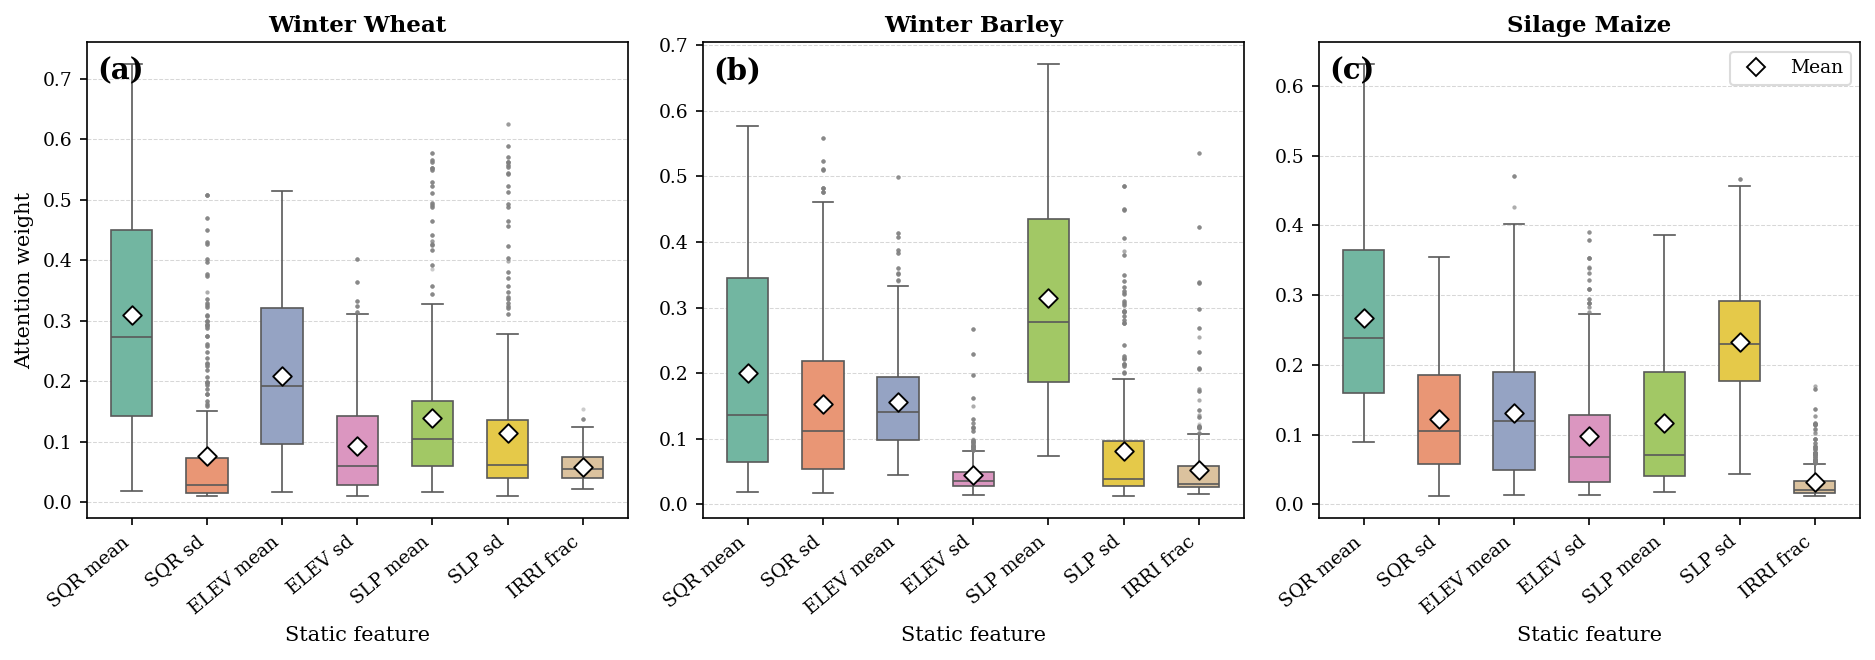

In [6]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Configuration ────────────────────────────────────────────────────────────
crops = ["winter_wheat", "winter_barley", "silage_maize"]

crop_labels = {
    "winter_wheat": "Winter Wheat",
    "winter_barley": "Winter Barley",
    "silage_maize": "Silage Maize",
}
panel_labels = ["(a)", "(b)", "(c)"]

# Map raw column names → short display labels (single-line, no \n)
static_var_labels = {
    "soil_quality_mean": "SQR mean",
    "soil_quality_stdDev": "SQR sd",
    "elevation_mean": "ELEV mean",
    "elevation_stdDev": "ELEV sd",
    "slope_mean": "SLP mean",
    "slope_stdDev": "SLP sd",
    "irrigated_fraction": "IRRI frac",
}

# Colour palette (one colour per static variable, consistent across panels)
var_list = list(static_var_labels.keys())
ordered_labels = [static_var_labels[v] for v in var_list]
palette = sns.color_palette("Set2", len(var_list))
var_color = dict(zip(ordered_labels, palette))

# ── Build long-format DataFrame for all crops ────────────────────────────────
long_records = []
for crop in crops:
    sdf = all_crop_results[crop]["CropFusionNet"]["static_weights_df"].copy()
    sdf = sdf[sdf["year"] >= 2019]
    for var in var_list:
        if var not in sdf.columns:
            continue
        tmp = sdf[["NUTS_ID", "year", var]].copy()
        tmp.rename(columns={var: "weight"}, inplace=True)
        tmp["variable"] = static_var_labels[var]
        tmp["crop"] = crop_labels[crop]
        tmp["variable_raw"] = var
        long_records.append(tmp)

long_df = pd.concat(long_records, ignore_index=True)
long_df["year"] = long_df["year"].astype(int)

# ── Export mean contribution per crop per static feature ─────────────────────
mean_contrib = (
    long_df.groupby(["crop", "variable_raw"])["weight"]
    .agg(mean_weight="mean", std_weight="std", median_weight="median")
    .reset_index()
)
# Add display label and reorder
mean_contrib["variable"] = mean_contrib["variable_raw"].map(static_var_labels)
mean_contrib["crop"] = pd.Categorical(
    mean_contrib["crop"], categories=[crop_labels[c] for c in crops], ordered=True
)
mean_contrib["variable_raw"] = pd.Categorical(
    mean_contrib["variable_raw"], categories=var_list, ordered=True
)
mean_contrib.sort_values(["crop", "variable_raw"], inplace=True)
mean_contrib = mean_contrib[
    ["crop", "variable_raw", "variable", "mean_weight", "std_weight", "median_weight"]
]
mean_contrib.reset_index(drop=True, inplace=True)

csv_path = os.path.join(
    "/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/output/tables",
    "static_feature_importance_mean.csv",
)
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
mean_contrib.to_csv(csv_path, index=False, float_format="%.6f")
print(f"CSV saved → {csv_path}")
# print(mean_contrib.to_string(index=False))

# ── Plot: 1 row × 3 columns (one panel per crop) ─────────────────────────────
fig, axes = plt.subplots(
    1,
    len(crops),
    figsize=(4.2 * len(crops), 4.5),
    dpi=150,
    sharey=False,  # each crop can have its own y-range
)

for ax, crop, panel in zip(axes, crops, panel_labels):
    label = crop_labels[crop]
    crop_df = long_df[long_df["crop"] == label].copy()

    sns.boxplot(
        data=crop_df,
        x="variable",
        y="weight",
        order=ordered_labels,
        palette=var_color,
        linewidth=0.8,
        width=0.55,
        flierprops=dict(
            marker="o",
            markersize=2.0,
            markerfacecolor="grey",
            markeredgewidth=0,
            alpha=0.4,
        ),
        ax=ax,
    )

    # Overlay mean markers
    means = crop_df.groupby("variable")["weight"].mean().reindex(ordered_labels)
    ax.scatter(
        np.arange(len(ordered_labels)),
        means.values,
        marker="D",
        s=40,
        color="white",
        edgecolors="k",
        linewidths=0.9,
        zorder=5,
    )

    # Panel label & title
    ax.text(
        0.02,
        0.97,
        panel,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
    )
    ax.set_title(label, fontsize=11, fontweight="bold", pad=5)

    # Axes labels — y-label only on leftmost panel
    if ax is axes[0]:
        ax.set_ylabel("Attention weight", fontsize=10)
    else:
        ax.set_ylabel("")

    ax.set_xlabel("Static feature", fontsize=10)

    # x-tick labels: rotated on every panel
    ax.set_xticks(range(len(ordered_labels)))
    ax.set_xticklabels(ordered_labels, rotation=40, ha="right", fontsize=9)

    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=9)

# Shared legend for mean marker
mean_marker = plt.Line2D(
    [],
    [],
    marker="D",
    linestyle="None",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="k",
    markeredgewidth=0.9,
    label="Mean",
)
axes[-1].legend(handles=[mean_marker], loc="upper right", fontsize=9, framealpha=0.7)
plt.tight_layout()

# Save figure
save_path = os.path.join(out_dir, "final", "static_feature_importance_all_crops.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Figure saved → {save_path}")
plt.show()

## Static Feature Importance — Spatial Maps (mean weight per NUTS3)


Figure saved → /beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany/output/figures/final/static_feature_importance_maps.png


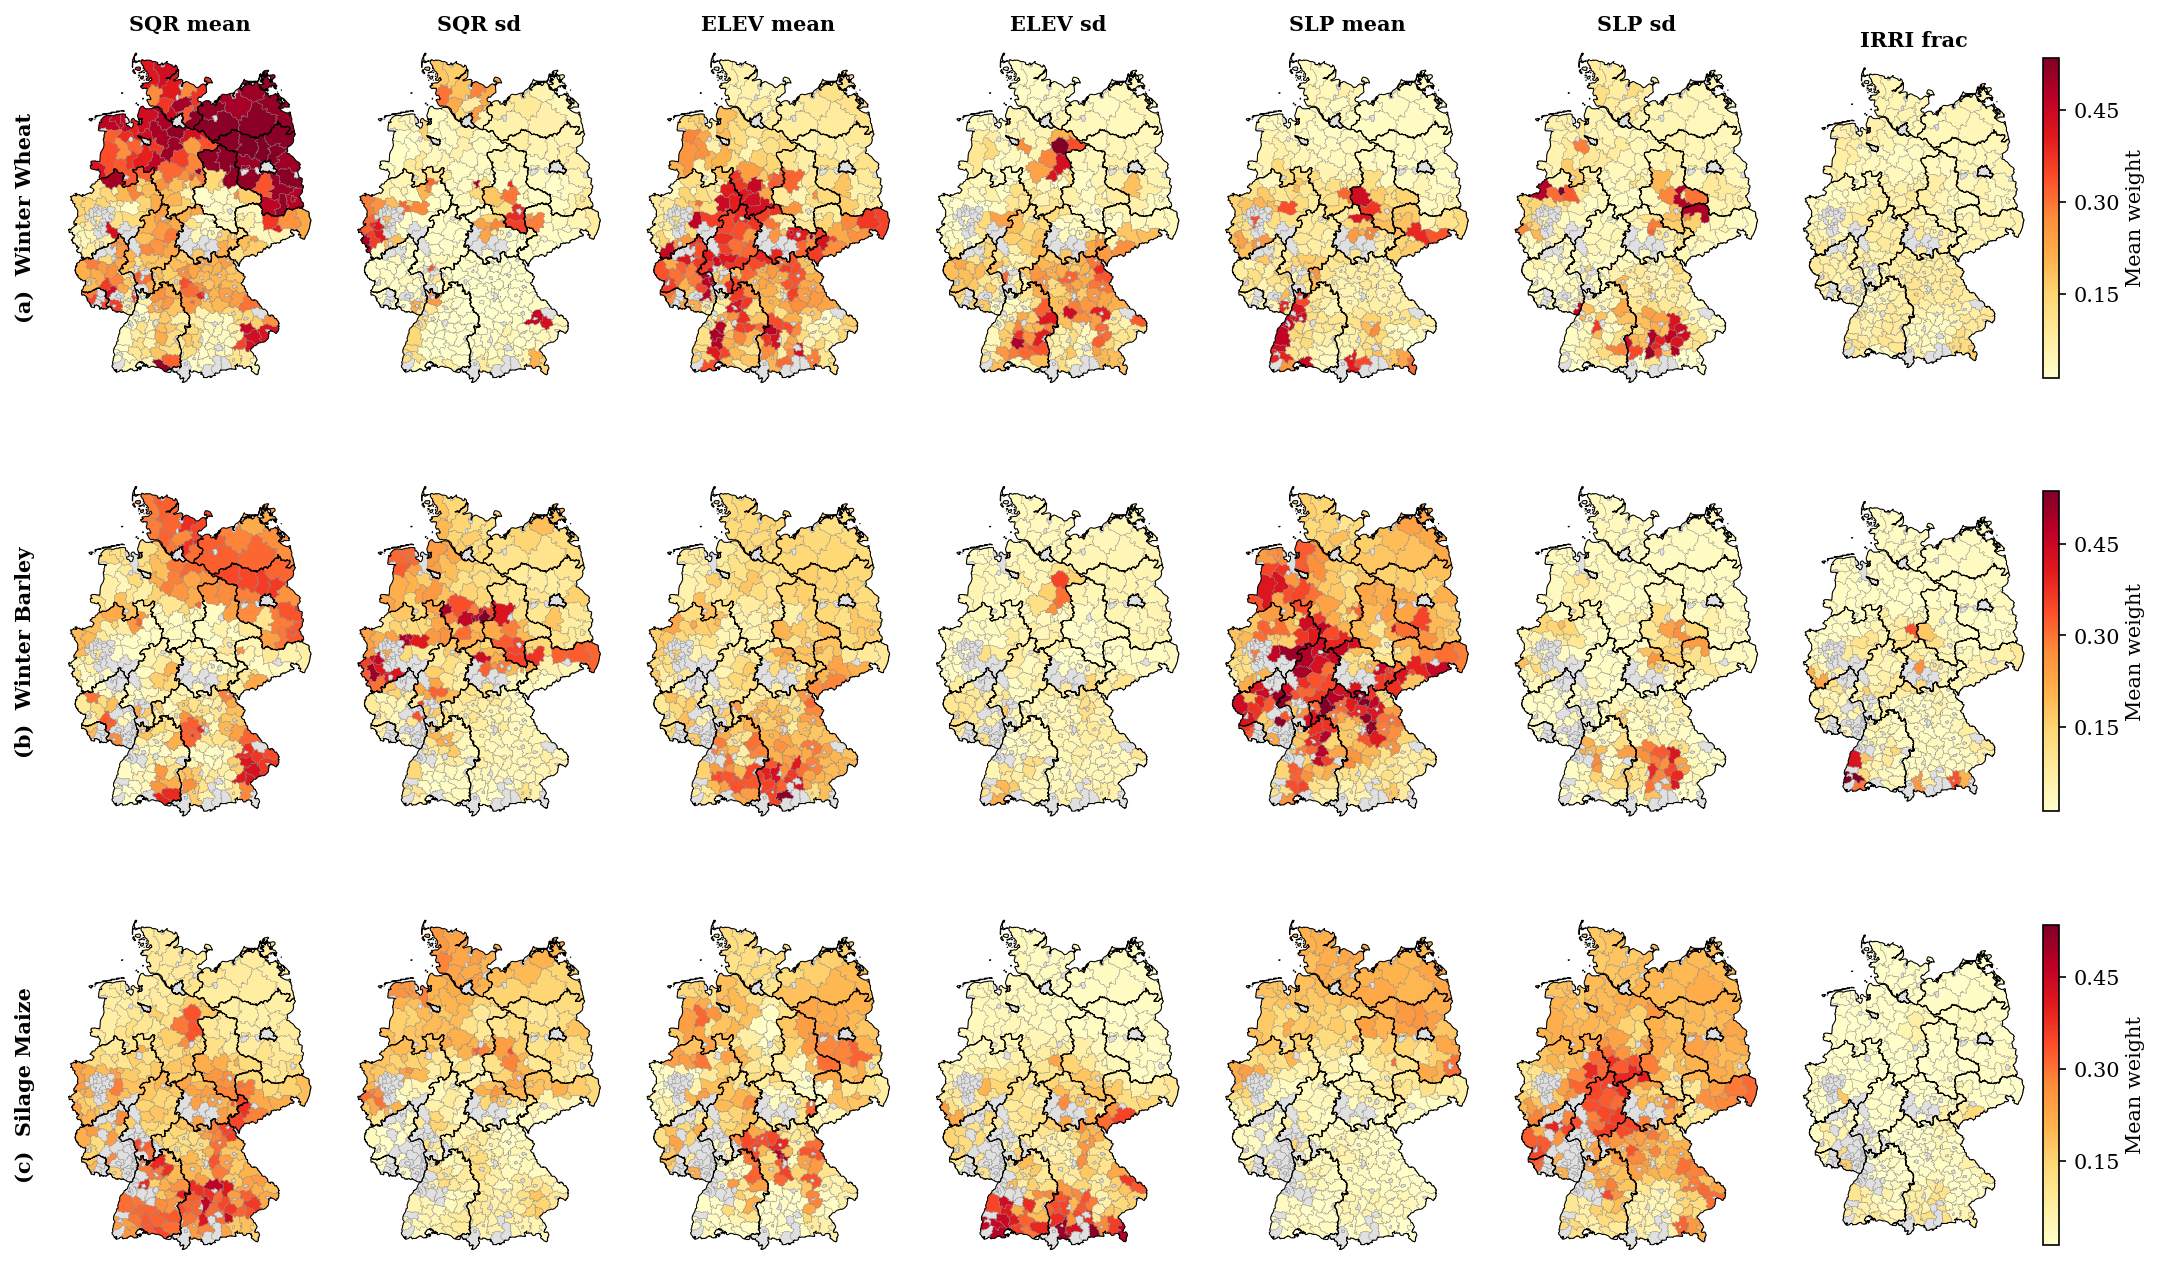

In [12]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Settings ──────────────────────────────────────────────────────────────────
crops = ["winter_wheat", "winter_barley", "silage_maize"]
crop_labels = {
    "winter_wheat": "Winter Wheat",
    "winter_barley": "Winter Barley",
    "silage_maize": "Silage Maize",
}
panel_rows = ["(a)", "(b)", "(c)"]  # one row per crop
n_vars = len(var_list)  # 7 static variables
n_crops = len(crops)

cmap = "YlOrRd"  # perceptually uniform, prints well in greyscale too

# ── Compute mean weight per NUTS_ID × variable_raw (across all years) ─────────
nuts_mean = (
    long_df.groupby(["crop", "variable_raw", "NUTS_ID"])["weight"]
    .mean()
    .reset_index()
    .rename(columns={"weight": "mean_weight"})
)

# ── Figure: rows = crops, cols = static variables ─────────────────────────────
fig, axes = plt.subplots(
    n_crops,
    n_vars,
    figsize=(2.2 * n_vars, 3.0 * n_crops),
    dpi=150,
)

for row_idx, crop in enumerate(crops):
    crop_label = crop_labels[crop]
    crop_df = nuts_mean[nuts_mean["crop"] == crop_label]

    for col_idx, var_raw in enumerate(var_list):
        ax = axes[row_idx, col_idx]
        var_label = static_var_labels[var_raw]

        # --- merge mean weights into GeoDataFrame ---
        var_df = crop_df[crop_df["variable_raw"] == var_raw][["NUTS_ID", "mean_weight"]]
        gdf = de_nuts3_gdf.merge(
            var_df, left_on="NUTS_ID", right_on="NUTS_ID", how="left"
        )

        # shared colour scale across all crops for this variable
        vmin = nuts_mean.loc[nuts_mean["variable_raw"] == var_raw, "mean_weight"].min()
        vmax = nuts_mean.loc[nuts_mean["variable_raw"] == var_raw, "mean_weight"].max()

        gdf.plot(
            column="mean_weight",
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor="grey",
            linewidth=0.15,
            legend=False,
            missing_kwds={"color": "#e0e0e0", "edgecolor": "grey", "linewidth": 0.15},
        )
        # NUTS1 state boundaries overlay
        de_nuts1_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

        ax.set_axis_off()

        # Column header (variable name) — only on first row
        if row_idx == 0:
            ax.set_title(var_label, fontsize=10, fontweight="bold", pad=3)

        # Row label (crop name + panel letter) — only on first column
        if col_idx == 0:
            ax.text(
                -0.08,
                0.5,
                f"{panel_rows[row_idx]}  {crop_label}",
                transform=ax.transAxes,
                fontsize=10,
                fontweight="bold",
                va="center",
                ha="right",
                rotation=90,
            )

        # Colorbar — only on last column
        if col_idx == n_vars - 1:
            sm = plt.cm.ScalarMappable(
                cmap=cmap,
                norm=plt.Normalize(vmin=vmin, vmax=vmax),
            )
            sm.set_array([])
            cbar = fig.colorbar(
                sm,
                ax=ax,
                orientation="vertical",
                fraction=0.06,
                pad=0.03,
                shrink=0.85,
            )
            cbar.ax.tick_params(labelsize=10)
            cbar.set_label("Mean weight", fontsize=10, labelpad=3)
            cbar.locator = mticker.MaxNLocator(nbins=4)
            cbar.update_ticks()

plt.tight_layout(rect=[0.06, 0, 1, 1])  # leave room for row labels

# ── Save ──────────────────────────────────────────────────────────────────────
map_save_path = os.path.join(out_dir, "final", "static_feature_importance_maps.png")
os.makedirs(os.path.dirname(map_save_path), exist_ok=True)
fig.savefig(map_save_path, bbox_inches="tight", dpi=300)
print(f"Figure saved → {map_save_path}")
plt.show()